# Fine-tuning Azure OpenAI GPT-4o for Chart Analysis
This notebook demonstrates the process of vision fine-tuning of GPT-4o leveraging a chart analysis benchmark dataset for visual and logical reasoning. It covers data preparation, fine-tuning, deployment, and evaluation against GPT-4o's baseline performance.

__Content:__
1. Retrieve and prepare dataset
2. Configure and start fine-tuning 
3. Deploy the fine-tuned model
4. Perform inference examples
5. Evaluate model baseline versus fine-tuned performance  

__Acknowledgements:__  
This project utilizes the ChartQA dataset introduced by Masry et al. in their paper, *ChartQA: A Benchmark for Question Answering about Charts with Visual and Logical Reasoning* (Findings of ACL 2022). We acknowledge the authors for providing this valuable resource. For more details, refer to the publication: [ChartQA: ACL 2022](https://aclanthology.org/2022.findings-acl.177).

## Setup

In [16]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import os
import json
from io import BytesIO, StringIO

import pandas as pd
from PIL import Image
import base64
import requests
from IPython.display import display, Markdown
from tqdm import tqdm
from tenacity import retry, stop_after_attempt, wait_fixed
from dotenv import load_dotenv, find_dotenv
from azure.identity import DefaultAzureCredential
import matplotlib.pyplot as plt

from datasets import load_dataset
from openai import AzureOpenAI

%config InlineBackend.figure_format = 'retina'

In [ ]:
# Central variables
project_name, version = "chart-qa", "dev-03" # for naming files and models
ft_model_deployment = f"{project_name}-{version}" # the name of your fine-tuned model deployment
base_model_deployment = "gpt-4.1" # deployment name (used for comparative evaluation)

# Dataset parameters
train_samples = 200
val_samples = 50
test_samples = 50
bold_start, bold_end = '\033[1m', '\033[0m'

SYSTEM_PROMPT = """You are a Vision Language Model specialized in interpreting visual data from chart images.
Your task is to analyze the provided chart image and respond to queries with concise answers, usually a single word, number, or short phrase.
The charts include a variety of types (e.g., line charts, bar charts) and contain colors, labels, and text.
Focus on delivering accurate, succinct answers based on the visual information. Avoid additional explanations unless absolutely necessary."""

if not load_dotenv(find_dotenv()): raise Exception(".env file not found")
api_key = os.getenv("AOAI_KEY")
azure_endpoint = os.getenv("AZURE_ENDPOINT")

# AOAI model deployment using the Control Plane API
subscription_id = os.getenv("SUBSCRIPTION_ID")
resource_name = os.getenv("AOAI_RESOURCE") # name of the AOAI resource
rg_name = os.getenv("RESOURCE_GROUP") # name of the resource group

client = AzureOpenAI(
    api_key=api_key,
    api_version="2024-10-21",
    azure_endpoint=azure_endpoint
)

## Helper functions

In [20]:
def encode_image(image, quality=95):
    """ Encode an image into a base64 string in JPEG format. """

    if image.mode != 'RGB':
        image = image.convert('RGB')  # Convert to RGB
    buffered = BytesIO()
    image.save(buffered, format="JPEG", quality=quality) 
    return base64.b64encode(buffered.getvalue()).decode("utf-8")

def date_sorted_df(details_dict):
    """ Create a pandas DataFrame from a dictionary and sort it by a 'created' or 'created_at' timestamp column for displaying OpenAI API tables. """
    df = pd.DataFrame(details_dict)
    
    if 'created' in df.columns:
        df.rename(columns={'created': 'created_at'}, inplace=True)
    
    # Convert 'created_at' from Unix timestamp to human-readable date/time format
    df['created_at'] = pd.to_datetime(df['created_at'], unit='s').dt.strftime('%Y-%m-%d %H:%M:%S')

    if 'finished_at' in df.columns:
        # Convert 'finished_at' from Unix timestamp to human-readable date/time format, keeping null values as is
        df['finished_at'] = pd.to_datetime(df['finished_at'], unit='s', errors='coerce').dt.strftime('%Y-%m-%d %H:%M:%S')
    
    # Sort DataFrame by 'created_at' in descending order
    df = df.sort_values(by='created_at', ascending=False)

    return df

def plot_learning_curves(df, smoothing_window=10):
    """
    Plots learning curves for a fine-tuning job with smoothing for train metrics.

    Parameters:
    df (pd.DataFrame): Dataframe containing the training and validation metrics.
    smoothing_window (int): Window size for rolling mean smoothing.
    """
    epochs = df[df['full_valid_loss'].notna()]['step'].values

    # Interpolate missing values for validation metrics
    df['valid_loss_interpolated'] = df['valid_loss'].interpolate()
    df['valid_mean_token_accuracy_interpolated'] = df['valid_mean_token_accuracy'].interpolate()

    # Compute smoothed train metrics
    df['train_loss_smoothed'] = df['train_loss'].rolling(window=smoothing_window, min_periods=1).mean()
    df['train_mean_token_accuracy_smoothed'] = df['train_mean_token_accuracy'].rolling(window=smoothing_window, min_periods=1).mean()

    # Initialize subplots
    fig, axs = plt.subplots(2, 2, figsize=(16, 10))

    # Plot Train Loss
    axs[0, 0].plot(df['step'], df['train_loss'], label='Train Loss (Original)', linewidth=0.5, alpha=0.7)
    axs[0, 0].plot(df['step'], df['train_loss_smoothed'], label='Train Loss (Smoothed)', linewidth=2, color='blue')
    for epoch in epochs:
        axs[0, 0].axvline(x=epoch, color='gray', linestyle='--', linewidth=0.5)
    axs[0, 0].set_title("Train Loss")
    axs[0, 0].set_xlabel("Step")
    axs[0, 0].set_ylabel("Loss")
    axs[0, 0].legend()

    # Plot Train Mean Token Accuracy
    axs[0, 1].plot(df['step'], df['train_mean_token_accuracy'], label='Train Mean Token Accuracy (Original)', linewidth=0.5, alpha=0.7, color='orange')
    axs[0, 1].plot(df['step'], df['train_mean_token_accuracy_smoothed'], label='Train Mean Token Accuracy (Smoothed)', linewidth=2, color='darkorange')
    for epoch in epochs:
        axs[0, 1].axvline(x=epoch, color='gray', linestyle='--', linewidth=0.5)
    axs[0, 1].set_title("Train Mean Token Accuracy")
    axs[0, 1].set_xlabel("Step")
    axs[0, 1].set_ylabel("Accuracy")
    axs[0, 1].legend()

    # Plot Validation Loss
    axs[1, 0].plot(df['step'], df['valid_loss_interpolated'], label='Validation Loss', color='green')
    axs[1, 0].scatter(df['step'], df['full_valid_loss'], color='red', label='Full Validation Loss (Epoch)', edgecolor='black')
    for epoch in epochs:
        axs[1, 0].axvline(x=epoch, color='gray', linestyle='--', linewidth=0.5)
    axs[1, 0].set_title("Validation Loss")
    axs[1, 0].set_xlabel("Step")
    axs[1, 0].set_ylabel("Loss")
    axs[1, 0].legend()

    # Plot Validation Mean Token Accuracy
    axs[1, 1].plot(df['step'], df['valid_mean_token_accuracy_interpolated'], label='Validation Mean Token Accuracy', color='purple')
    axs[1, 1].scatter(df['step'], df['full_valid_mean_token_accuracy'], color='red', label='Full Validation Accuracy (Epoch)', edgecolor='black')
    for epoch in epochs:
        axs[1, 1].axvline(x=epoch, color='gray', linestyle='--', linewidth=0.5)
    axs[1, 1].set_title("Validation Mean Token Accuracy")
    axs[1, 1].set_xlabel("Step")
    axs[1, 1].set_ylabel("Accuracy")
    axs[1, 1].legend()

    plt.tight_layout()
    plt.show()


@retry(stop=stop_after_attempt(3), wait=wait_fixed(10))
def query_image(image, question, deployment):
    """ Query an image with a question using a specified deployment. """
    
    encoded_image_url = f"data:image/jpeg;base64,{encode_image(image, quality=95)}"

    response = client.chat.completions.create(
        model=deployment,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": [
                {"type": "text", "text": question},
                {"type": "image_url", "image_url": {"url": encoded_image_url}}
            ]}
        ],
        temperature=0,
        seed=0,
    )

    return response.choices[0].message.content


def compare(idx, df, base_model_deployment=base_model_deployment, ft_model_deployment=ft_model_deployment):
    """ Compare the performance of base and fine-tuned models on a given sample. """
    question = df.iloc[idx]['question']
    img = df.iloc[idx]['image']
    ground_truth_answer = df.iloc[idx]['answer']

    base_model_answer = query_image(img, question, base_model_deployment)
    ft_model_answer = query_image(img, question, ft_model_deployment)

    # Display the image
    display(img)

    # Display the question
    display(Markdown(f"**Question:** {question}"))

    # Create a DataFrame with the answers
    answers_df = pd.DataFrame({
        'Ground Truth': [ground_truth_answer],
        'Base Model Answer': [base_model_answer],
        'Fine-Tuned Model Answer': [ft_model_answer]
    })

    # Convert the DataFrame to a Markdown table
    markdown_table = answers_df.to_markdown(index=False)

    # Display the Markdown table
    display(Markdown(markdown_table))

## Retrieve and prepare dataset

Fine-tuning for images is possible with JSONL dataset files similar to the process of sending images as input to the chat completion API.
Images can be provided as HTTP URLs (as shown below) or data URLs containing base64-encoded images.

```json
{
  "messages": [
    { "role": "system", "content": "You are an assistant that identifies uncommon cheeses." },
    { "role": "user", "content": "What is this cheese?" },
    { "role": "user", "content": [
        {
          "type": "image_url",
          "image_url": {
            "url": "https://upload.wikimedia.org/wikipedia/commons/3/36/Danbo_Cheese.jpg"
          }
        }
      ]
    },
    { "role": "assistant", "content": "Danbo" }
  ]
}
```
The following cell converts the ChartQA dataset from HuggingFace into this JSONL format by using base64-encoded images. Depending on your training data format, you will likely need to perform a few changes for reusing the code for your other use cases. 

In [21]:
ds = load_dataset("HuggingFaceM4/ChartQA")
print("Original dataset:")
display(ds)

# convert to pandas dataframe
ds_train = ds['train'].to_pandas()
ds_val = ds['val'].to_pandas()
ds_test = ds['test'].to_pandas()

# consider only human-labelled images
ds_train = ds_train[ds_train['human_or_machine']==0]
ds_val = ds_val[ds_val['human_or_machine']==0]
ds_test = ds_test[ds_test['human_or_machine']==0]

# Sample training, validation, and test examples
ds_train = ds_train.sample(train_samples, random_state=42)
ds_val = ds_val.sample(val_samples, random_state=42)
ds_test = ds_test.sample(test_samples, random_state=42)

# convert byte strings to PIL images. Retains original quality 
ds_train['image'] = ds_train['image'].apply(lambda x: Image.open(BytesIO(x['bytes'])))
ds_val['image'] = ds_val['image'].apply(lambda x: Image.open(BytesIO(x['bytes'])))
ds_test['image'] = ds_test['image'].apply(lambda x: Image.open(BytesIO(x['bytes'])))

# Convert array type of 'label' column into string only if the current data type is object
if ds_train['label'].dtype == 'object':
    ds_train['label'] = ds_train['label'].apply(lambda x: x[0])

if ds_val['label'].dtype == 'object':
    ds_val['label'] = ds_val['label'].apply(lambda x: x[0])

if ds_test['label'].dtype == 'object':
    ds_test['label'] = ds_test['label'].apply(lambda x: x[0])

# rename columns
ds_train = ds_train.rename(columns={'query': 'question', 'label': 'answer'})
ds_val = ds_val.rename(columns={'query': 'question', 'label': 'answer'})
ds_test = ds_test.rename(columns={'query': 'question', 'label': 'answer'})

print("Fine-tuning scope:\n")
print(f"Training examples: {ds_train.shape[0]}")
print(f"Validation examples: {ds_val.shape[0]}")
print(f"Test examples: {ds_test.shape[0]}")

Original dataset:


DatasetDict({
    train: Dataset({
        features: ['image', 'query', 'label', 'human_or_machine'],
        num_rows: 28299
    })
    val: Dataset({
        features: ['image', 'query', 'label', 'human_or_machine'],
        num_rows: 1920
    })
    test: Dataset({
        features: ['image', 'query', 'label', 'human_or_machine'],
        num_rows: 2500
    })
})

Fine-tuning scope:

Training examples: 2000
Validation examples: 500
Test examples: 500


QUESTION: Is the median of green bars and blue bars equal?


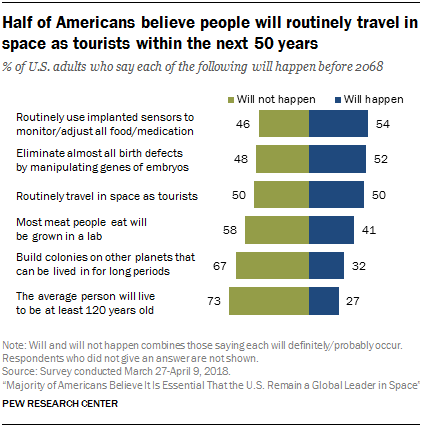

ANSWER: No


In [22]:
# review a random training example
idx=0

print('QUESTION:', ds_train.iloc[idx]['question'])
display(ds_train.iloc[idx]['image'])

print('ANSWER:', ds_train.iloc[idx]['answer'])

In [26]:
# Create dataset splits as local JSONL files compatible with the fine-tuning API
splits = ['train', 'val', 'test']
datasets = [ds_train, ds_val, ds_test]

for split, dataset in zip(splits, datasets):
    dataset_file = f"{project_name}-{version}-{split}.jsonl"
    print(f"Generating {dataset_file} with {dataset.shape[0]} samples.")
    
    json_data = []
    base64_prefix = "data:image/jpeg;base64,"
    
    for idx, example in tqdm(enumerate(dataset.itertuples()), total=dataset.shape[0]):
        try:
            system_message = {"role": "system", "content": SYSTEM_PROMPT}
            
            encoded_image = encode_image(example.image, quality=95)
            user_message = {
                "role": "user",
                "content": [
                    {"type": "text", "text": f"Question [{idx}]: {example.question}"},
                    {"type": "image_url", "image_url": {"url": f"{base64_prefix}{encoded_image}"}}
                ]
            }
            assistant_message = {"role": "assistant", "content": example.answer}

            json_data.append({"messages": [system_message, user_message, assistant_message]})
        except KeyError as e:
            print(f"Missing field in example {idx}: {e}")
        except Exception as e:
            print(f"Error processing example {idx}: {e}")
    
    with open(dataset_file, "w") as f:
        for message in json_data:
            json.dump(message, f)
            f.write("\n")

Generating chart-qa-dev-03-train.jsonl with 2000 samples.


  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:07<00:00, 259.83it/s]


Generating chart-qa-dev-03-val.jsonl with 500 samples.


100%|██████████| 500/500 [00:01<00:00, 254.73it/s]


Generating chart-qa-dev-03-test.jsonl with 500 samples.


100%|██████████| 500/500 [00:01<00:00, 261.26it/s]


## Configure and start fine-tuning job

In [24]:
# upload training file
train_file = client.files.create(
  file=open(f"{project_name}-{version}-train.jsonl", "rb"),
  purpose="fine-tune"
)

# upload validation file
val_file = client.files.create(
  file=open(f"{project_name}-{version}-val.jsonl", "rb"),
  purpose="fine-tune"
)

Here is some guidance if you want to adjust the hyperparameters of the fine-tuning process. You can keep them as `None` to use default values. 

| Hyperparameter                       | Description                                                                                                                                                                              |
|-----------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `Batch size`                            | The batch size to use for training. When set to default, batch_size is calculated as 0.2% of examples in training set and the max is 256.                                                           |
| `Learning rate multiplier` | The fine-tuning learning rate is the original learning rate used for pre-training multiplied by this multiplier. We recommend experimenting with values between 0.5 and 2. Empirically, we've found that larger learning rates often perform better with larger batch sizes. Must be between 0.0 and 5.0. |
| `Number of epochs`       | Number of training epochs. An epoch refers to one full cycle through the data set. If set to default, number of epochs will be determined dynamically based on the input data. |
| `Seed`  | The seed controls the reproducibility of the job. Passing in the same seed and job parameters should produce the same results, but may differ in rare cases. If a seed is not specified, one will be generated for you. |

In [15]:
# create fine tuning job
file_train = train_file.id
file_val = val_file.id

suffix = f"{project_name}-{version}"
model_name = os.getenv("BASE_MODEL", "gpt-4.1")

ft_job = client.fine_tuning.jobs.create(
  suffix=suffix,
  training_file=file_train,
  validation_file=file_val, # optional
  model=model_name, # base model name or existing checkpoint (not the deployment name)
  seed=None,
  method={
      "type" : "supervised",
      "supervised" : {"hyperparameters" : {"n_epochs" : None,
                      "batch_size" : None,
                      "learning_rate_multiplier" : None,}
       }
  }
)

Using base model deployment: gpt-4o


In [25]:
# List 5 recent fine-tuning jobs
ft_jobs = client.fine_tuning.jobs.list(limit=5).to_dict()

display(date_sorted_df(pd.DataFrame(ft_jobs['data'])))

,id,created_at,fine_tuned_model,finished_at,hyperparameters,model,object,result_files,seed,status,trained_tokens,training_file,validation_file,estimated_finish,suffix
0,ftjob-8f3d74e417e14b818ce332776b1f1107,2026-03-09 05:00:19,gpt-4.1-2025-04-14.ft-8f3d74e417e14b818ce33277...,2026-03-09 06:55:46,"{'batch_size': 1, 'learning_rate_multiplier': ...",gpt-4.1-2025-04-14,fine_tuning.job,[file-9b50ba00fdb34d2587b21207ead26811],416472544,succeeded,7358355.0,file-04aa411470f0487f827a4c9862e94979,file-66c8d4bc09de4b898737df5c1079676b,1773181083,bank-sft-1
1,ftjob-268d9d95639c4a269e2a9a34ced015a2,2026-03-09 04:27:44,NaN,2026-03-09 09:09:58,"{'batch_size': -1, 'learning_rate_multiplier':...",gpt-4o-2024-08-06,fine_tuning.job,NaN,376066581,cancelled,NaN,file-836ce47479ee428d867c78b123328f0d,file-835fe33cbf084d3e8369dab5d97791ad,1774634526,chart-qa-dev-02
2,ftjob-495fb1ff02b145f79a6d5464171abb4a,2026-03-09 02:20:43,NaN,2026-03-09 09:09:53,"{'batch_size': 4, 'learning_rate_multiplier': ...",o4-mini-2025-04-16,fine_tuning.job,NaN,582267198,cancelled,NaN,file-6dc4f687cb444618967bd4dc79194723,file-63235b2b6db841d796291870d55c5164,1774614204,countdown-rft
3,ftjob-df808a7c04ac409d9b18e06fd92c002e,2026-03-07 22:30:14,NaN,2026-03-09 07:50:41,"{'batch_size': 1, 'learning_rate_multiplier': ...",gpt-4.1-2025-04-14,fine_tuning.job,[file-bb838828c6a84245a582b634050ff41f],1967945461,cancelled,NaN,file-597a2182063841358ae088cf2ba907bc,file-d00a594cf7794d4ea53c4b81ca4a1ffe,1774608684,NaN
4,ftjob-b2d21716f5574ac9ae677d001d3c3424,2026-03-07 21:58:12,gpt-4o-2024-08-06.ft-b2d21716f5574ac9ae677d001...,2026-03-08 08:54:40,"{'batch_size': 1, 'learning_rate_multiplier': ...",gpt-4o-2024-08-06,fine_tuning.job,[file-fba0926913b148e88dc6c9a4543fbee1],1789123278,succeeded,13218042.0,file-e33bf5b462024bae81130dba041f6267,file-2423810afab94ea78d308e68cf58a30b,1772955097,chart-qa-dev-01


In [4]:
# Retrieve a specific job by ID
ft_job = client.fine_tuning.jobs.retrieve("ftjob-b2d21716f5574ac9ae677d001d3c3424")


In [5]:
display(ft_job.to_dict())

{'id': 'ftjob-b2d21716f5574ac9ae677d001d3c3424',
 'created_at': 1772920692,
 'fine_tuned_model': 'gpt-4o-2024-08-06.ft-b2d21716f5574ac9ae677d001d3c3424-chart-qa-dev-01',
 'finished_at': 1772960080,
 'hyperparameters': {'batch_size': 1,
  'learning_rate_multiplier': 1.0,
  'n_epochs': 3},
 'model': 'gpt-4o-2024-08-06',
 'object': 'fine_tuning.job',
 'result_files': ['file-fba0926913b148e88dc6c9a4543fbee1'],
 'seed': 1789123278,
 'status': 'succeeded',
 'trained_tokens': 13218042,
 'training_file': 'file-e33bf5b462024bae81130dba041f6267',
 'validation_file': 'file-2423810afab94ea78d308e68cf58a30b',
 'estimated_finish': 1772955097,
 'suffix': 'chart-qa-dev-01'}

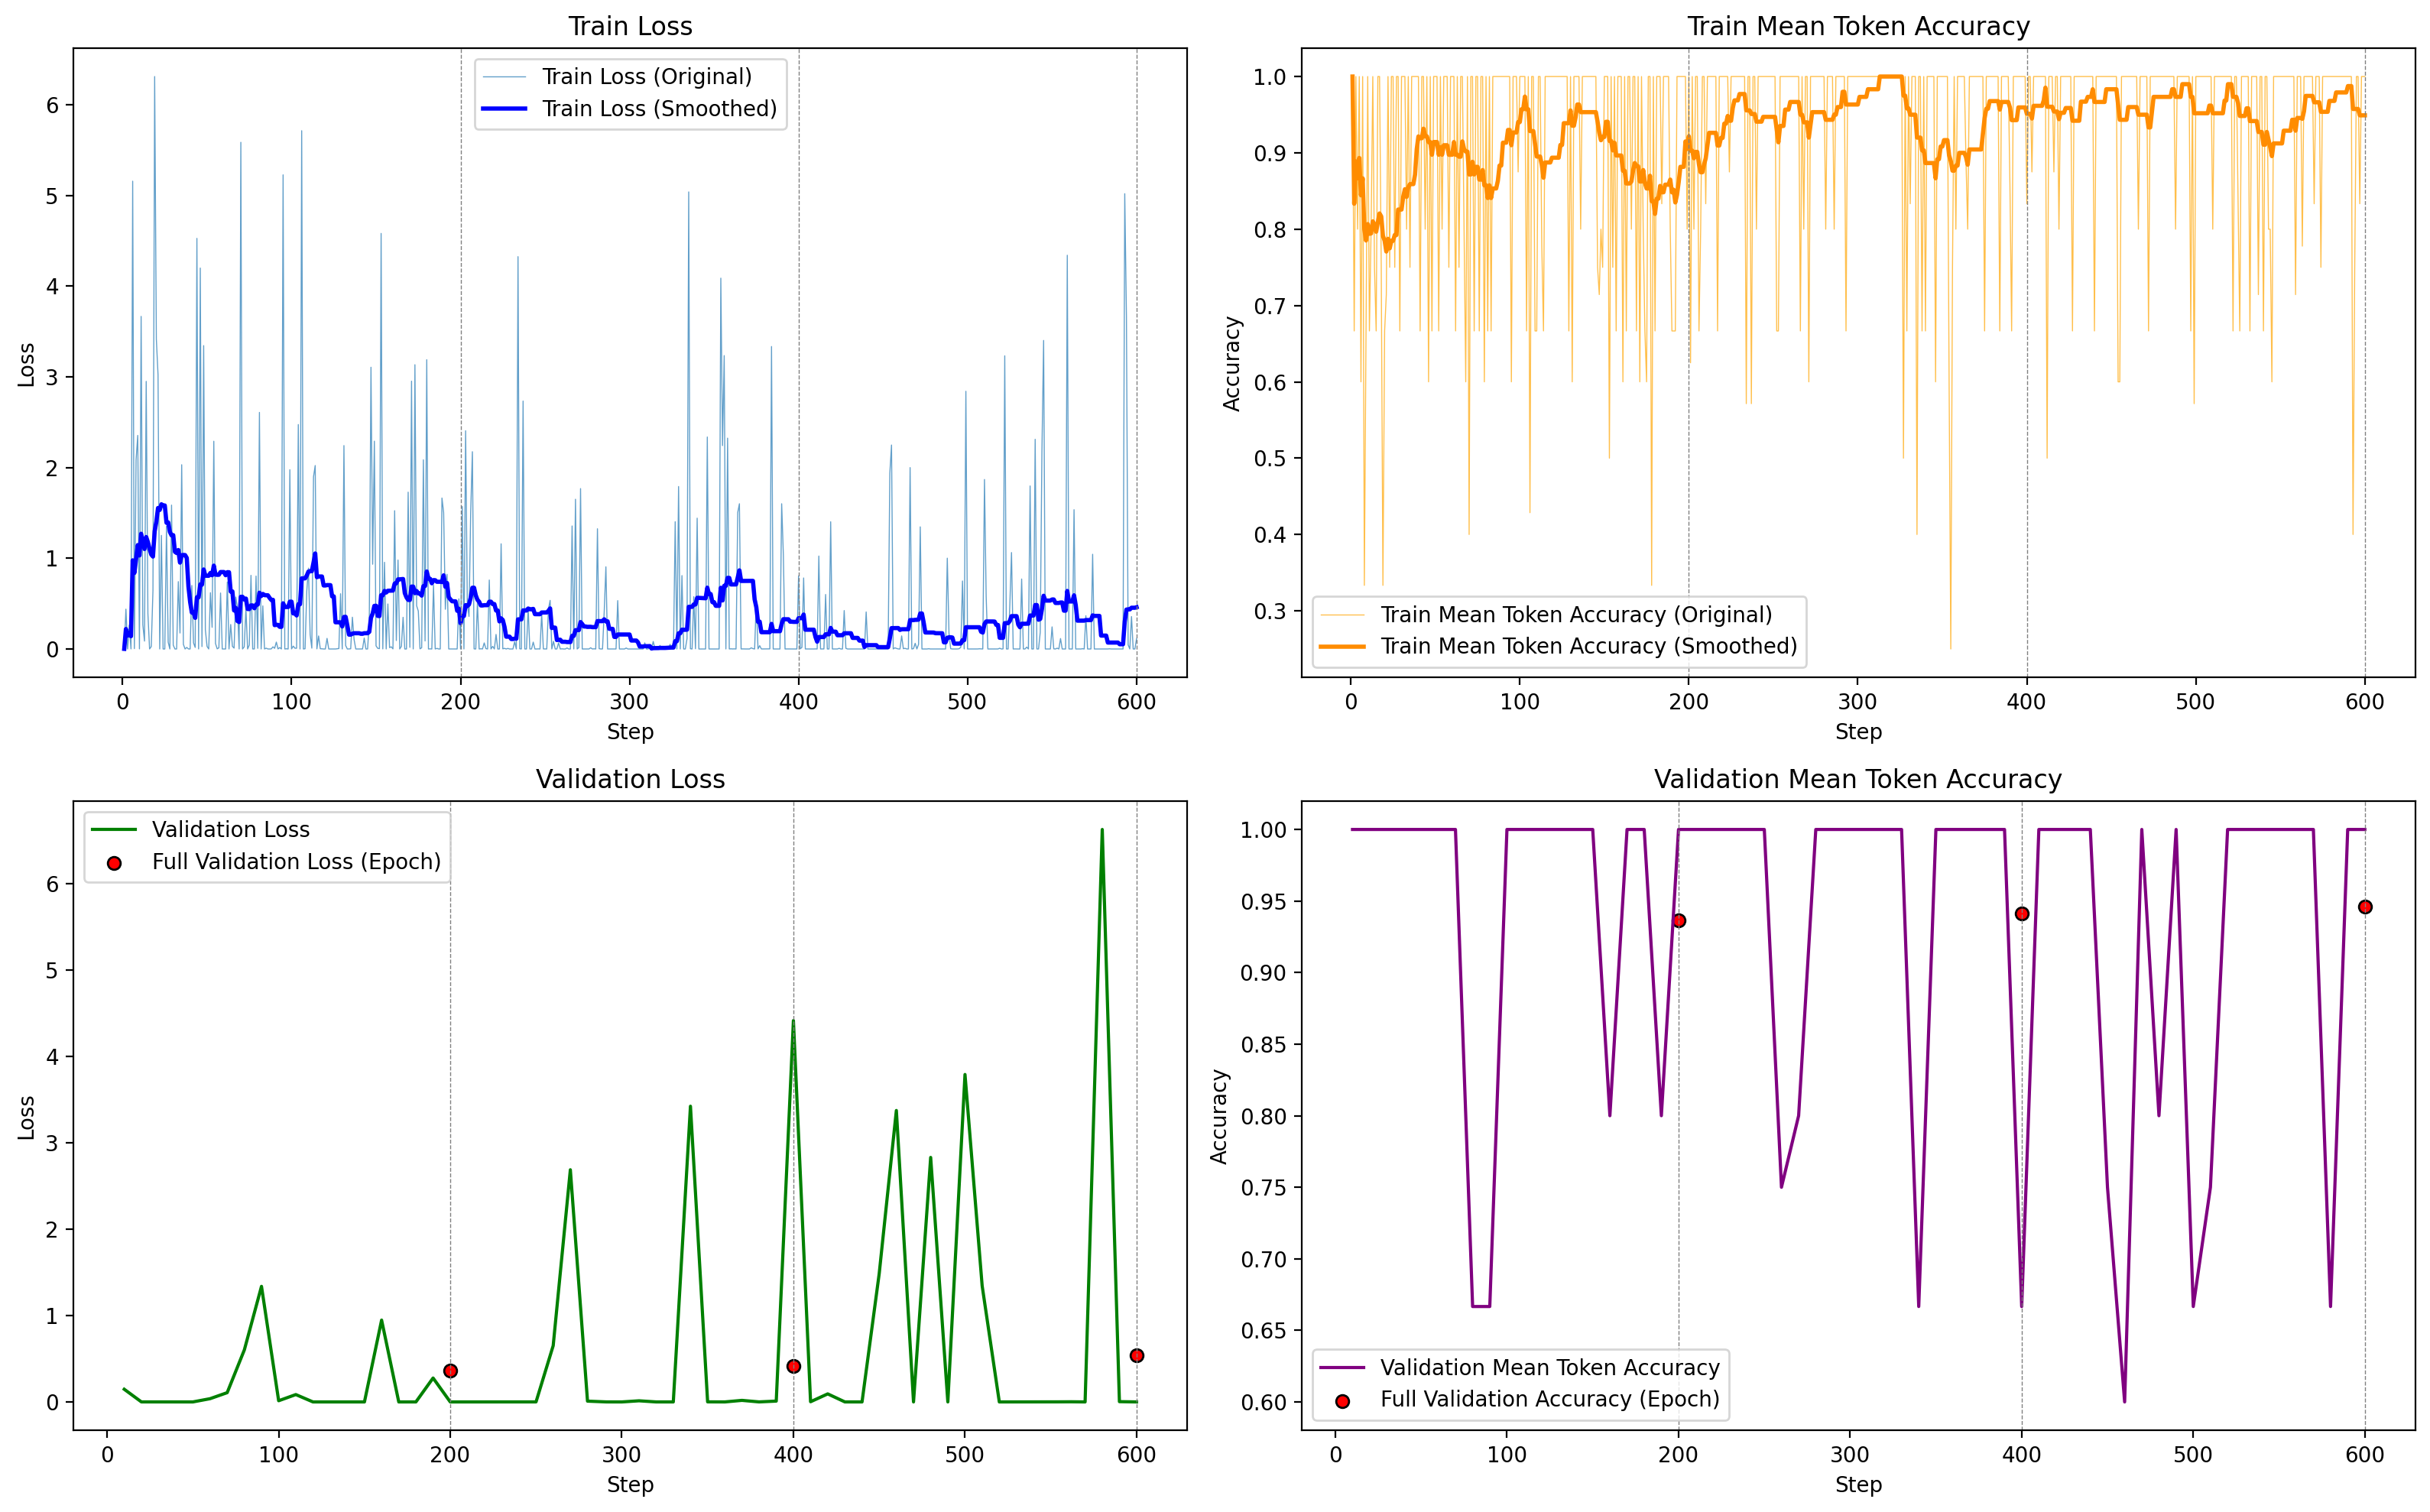

In [6]:
# Retrieve fine-tuning metrics from result file

result_file_id = ft_job.to_dict()['result_files'][0]
results_content = client.files.content(result_file_id).content.decode()

data_io = StringIO(results_content)

results_df = pd.read_csv(data_io)

plot_learning_curves(results_df, smoothing_window=20)

Take a look at this table for an interpretation of above diagrams:  

| Metric                       | Description                                                                                                                                                                              |
|-----------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `step`                            | The number of the training step. A training step represents a single pass, forward and backward, on a batch of training data.                                                           |
| `train_loss`, `validation_loss` | The loss for the training / validation batch |
| `train_mean_token_accuracy`       | The percentage of tokens in the training batch correctly predicted by the model. For example, if the batch size is set to 3 and your data contains completions [[1, 2], [0, 5], [4, 2]], this value is set to 0.83 (5 of 6) if the model predicted [[1, 1], [0, 5], [4, 2]]. |
| `validation_mean_token_accuracy`  | The percentage of tokens in the validation batch correctly predicted by the model. For example, if the batch size is set to 3 and your data contains completions [[1, 2], [0, 5], [4, 2]], this value is set to 0.83 (5 of 6) if the model predicted [[1, 1], [0, 5], [4, 2]]. |

## Deploy fine-tuned model

You can use the Azure AI Foundry portal to perform a manual deployment from your job under the __Fine-tuning__ menu.

If you prefer an automated  approach, the following code shows how to deploy the model using the Control Plane API. Take a look at the [Azure OpenAI fine-tuning documentation](https://learn.microsoft.com/en-us/azure/ai-services/openai/how-to/fine-tuning?tabs=turbo&pivots=programming-language-python#deploy-fine-tuned-model) for more details.

In [7]:
# List existing models
my_models = client.models.list().to_dict()

models_df = date_sorted_df(my_models['data'])

cols = ['status', 'capabilities', 'lifecycle_status', 'id', 'created_at', 'model']
print(f'Models of AOAI resource {bold_start}{resource_name}{bold_end}:')
display(models_df[cols].head())

Models of AOAI resource fsi-foundry:


,status,capabilities,lifecycle_status,id,created_at,model
324,succeeded,"{'fine_tune': False, 'inference': True, 'compl...",generally-available,gpt-4o-2024-08-06.ft-b2d21716f5574ac9ae677d001...,2026-03-07 21:58:12,gpt-4o-2024-08-06
323,succeeded,"{'fine_tune': False, 'inference': True, 'compl...",generally-available,gpt-4o-2024-08-06.ft-b2d21716f5574ac9ae677d001...,2026-03-07 21:58:12,gpt-4o-2024-08-06
322,succeeded,"{'fine_tune': False, 'inference': True, 'compl...",generally-available,gpt-4o-2024-08-06.ft-b2d21716f5574ac9ae677d001...,2026-03-07 21:58:12,gpt-4o-2024-08-06
321,succeeded,"{'fine_tune': False, 'inference': True, 'compl...",generally-available,gpt-4.1-2025-04-14.ft-78d28ad4a0f149e093c14c3b...,2026-03-07 21:42:12,gpt-4.1-2025-04-14
320,succeeded,"{'fine_tune': False, 'inference': True, 'compl...",generally-available,gpt-4.1-2025-04-14.ft-78d28ad4a0f149e093c14c3b...,2026-03-07 21:42:12,gpt-4.1-2025-04-14


In [ ]:
fine_tuned_model = ft_job.to_dict()['fine_tuned_model'] # retrieve this value from the previous calls. Can also be a checkpoint name.

credential = DefaultAzureCredential()
token = credential.get_token("https://management.azure.com/.default").token

deploy_params = {'api-version': "2024-10-01"} 
deploy_headers = {'Authorization': 'Bearer {}'.format(token), 'Content-Type': 'application/json'}

deploy_data = {
    "sku": {"name": "GlobalStandard", "capacity": 50}, # in 1000 tokens per min
    "properties": {
        "model": {
            "format": "OpenAI",
            "name": fine_tuned_model, 
            "version": "1"
        }
    }
}
deploy_data = json.dumps(deploy_data)

request_url = f'https://management.azure.com/subscriptions/{subscription_id}/resourceGroups/{rg_name}/providers/Microsoft.CognitiveServices/accounts/{resource_name}/deployments/{ft_model_deployment}'

print('Creating a new deployment...')

r = requests.put(request_url, params=deploy_params, headers=deploy_headers, data=deploy_data)

print(r)
print(r.reason)
print(r.json())

Creating a new deployment...
<Response [201]>
Created
{'id': '/subscriptions/873a4995-e21b-47e2-953e-f2e88e2fa4f9/resourceGroups/rg-fsi/providers/Microsoft.CognitiveServices/accounts/fsi-foundry/deployments/chart-qa-dev-01', 'type': 'Microsoft.CognitiveServices/accounts/deployments', 'name': 'chart-qa-dev-01', 'sku': {'name': 'GlobalStandard', 'capacity': 100}, 'properties': {'model': {'format': 'OpenAI', 'name': 'gpt-4o-2024-08-06.ft-b2d21716f5574ac9ae677d001d3c3424-chart-qa-dev-01', 'version': '1'}, 'versionUpgradeOption': 'NoAutoUpgrade', 'currentCapacity': 100, 'capabilities': {'area': 'US', 'chatCompletion': 'true', 'assistants': 'true', 'jsonSchemaResponse': 'true', 'maxContextToken': '128000', 'maxOutputToken': '16384', 'responses': 'true', 'agentsV2': 'true'}, 'raiPolicyName': 'Microsoft.DefaultV2', 'provisioningState': 'Creating', 'rateLimits': [{'key': 'request', 'renewalPeriod': 10, 'count': 100}, {'key': 'token', 'renewalPeriod': 60, 'count': 100000}]}, 'systemData': {'crea